# Employee Attrition Prediction 
# XYlofy AI Internship Week 2

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1470
Columns: 35


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [7]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [11]:
(
    df["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns

print("Number of Numerical Columns:", len(numeric_cols))
print(numeric_cols.tolist())

Number of Numerical Columns: 26
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [13]:
categorical_cols = df.select_dtypes(include="object").columns

print("Number of Categorical Columns:", len(categorical_cols))
print(categorical_cols.tolist())

Number of Categorical Columns: 9
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22260\2281626446.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [14]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [15]:
df.describe(include="object")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22260\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


# Day 1 Observations

## Dataset Summary

- Dataset contains 1470 employee records.
- Dataset contains 35 columns.
- Target variable is Attrition.
- No missing values found.
- No duplicate records found.
- Dataset contains both numerical and categorical features.
- Attrition dataset is imbalanced.
- Several categorical variables will require encoding before model training.

## Next Step 

Day 2  will focus on:
- Data Cleaning 
- Feature Encoding
- Preparing data for Machine Learning.

# Day 2: Data Cleaning & Preprocessing

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [17]:
# Check constant columns
for col in df.columns:
    if df[col].nunique() == 1:
        print(col)

EmployeeCount
Over18
StandardHours


In [18]:
# Drop constant columns safely
df = df.drop(
    columns=["EmployeeCount", "Over18", "StandardHours"],
    errors="ignore"
)

print(df.shape)

(1470, 32)


In [19]:
# Encode target variable FIRST
df["Attrition"] = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [20]:
# Separate features and target BEFORE encoding feature columns
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print(X.shape)
print(y.shape)

(1470, 31)
(1470,)


In [21]:
# Encode only categorical feature columns, NOT target
categorical_cols = X.select_dtypes(include="object").columns

label_encoder = LabelEncoder()

for col in categorical_cols:
    X[col] = label_encoder.fit_transform(X[col])

print("Encoding completed successfully.")
print(X.shape)

Encoding completed successfully.
(1470, 31)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22260\1975156660.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


In [22]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1176, 31)
X_test: (294, 31)
y_train: (1176,)
y_test: (294,)


In [23]:
# Save cleaned dataset correctly
cleaned_df = X.copy()
cleaned_df["Attrition"] = y

cleaned_df.to_csv("data/Employee_Attrition_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")
print(cleaned_df.shape)

Cleaned dataset saved successfully.
(1470, 32)


# Day 2 Markdown

## Data Cleaning Summary

- Removed constant columns:
  - EmployeeCount
  - Over18
  - StandardHours

- Encoded target variable:
  - No → 0
  - Yes → 1

- Separated features and target before encoding feature columns.
- Label encoded only categorical feature columns.
- Used stratified 80/20 train-test split to preserve class balance.

## Final Dataset

- Rows: 1470
- Feature columns: 31
- Target column: Attrition

Dataset is now ready for Exploratory Data Analysis and Machine Learning.

# Day 3: Exploratory Data Analysis (EDA)

In [24]:
import os
os.makedirs("charts", exist_ok=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22260\1653132498.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


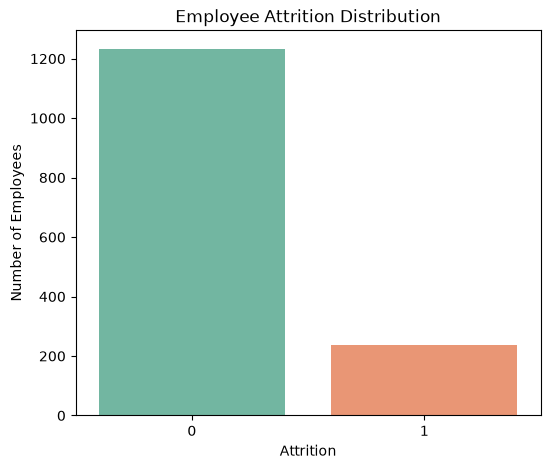

In [25]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="Attrition",
    data=df,
    palette="Set2"
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.savefig(
    "charts/attrition_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

- Majority of employees did not leave the company.
- Attrtion dataset is imbalanced.
- Around 16% employees left.

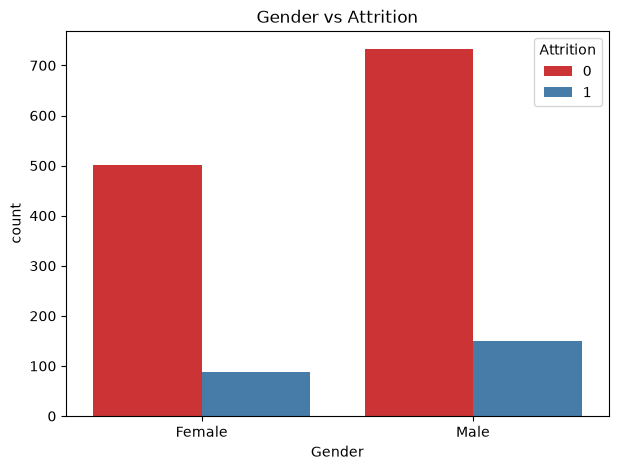

In [26]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Gender",
    hue="Attrition",
    data=df,
    palette="Set1"
)

plt.title("Gender vs Attrition")

plt.savefig(
    "charts/gender_attrition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Compare attrition between male and female employees.
- Observe whether one gender has noticeably higher attrition.

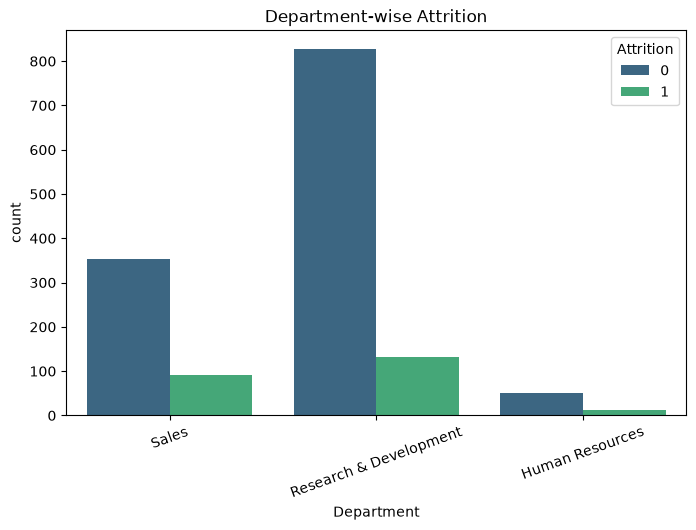

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Department",
    hue="Attrition",
    data=df,
    palette="viridis"
)

plt.xticks(rotation=20)

plt.title("Department-wise Attrition")

plt.savefig(
    "charts/department_attrition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Research & Development has the highest number of employees.
- Compare which department experiences higher employee turnover.

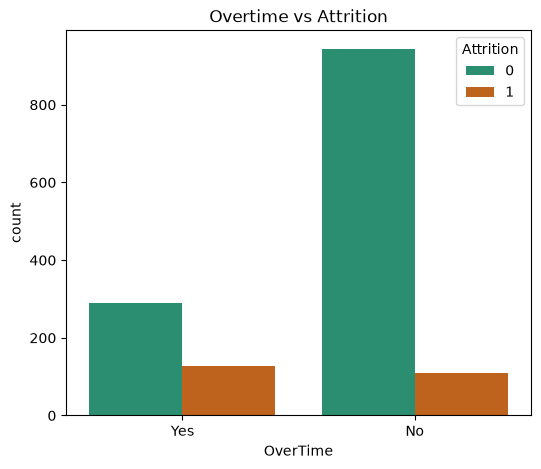

In [28]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="OverTime",
    hue="Attrition",
    data=df,
    palette="Dark2"
)

plt.title("Overtime vs Attrition")

plt.savefig(
    "charts/overtime_attrition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Employees working overtime appear more likely to leave.
- Overtime may be a major factor influencing attrition.

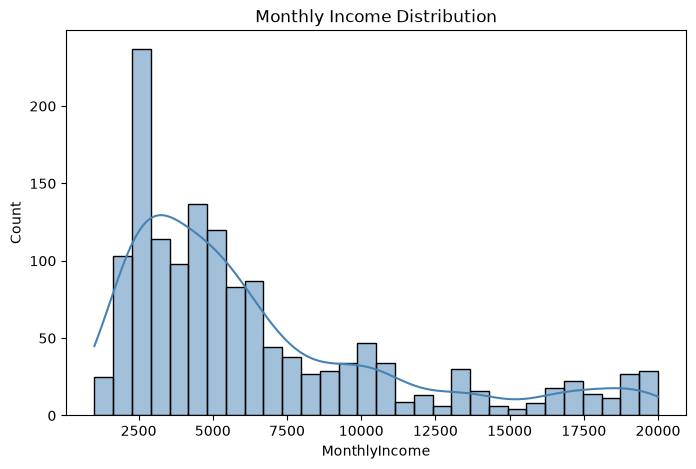

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MonthlyIncome"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Monthly Income Distribution")

plt.savefig(
    "charts/monthly_income_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Income is right-skewed.
- Most employees fall into the lower income range.

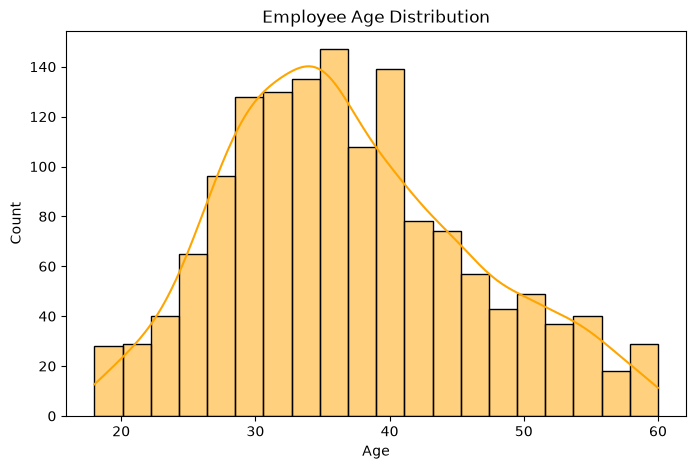

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=20,
    kde=True,
    color="orange"
)

plt.title("Employee Age Distribution")

plt.savefig(
    "charts/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Most employees are between 30–40 years old.

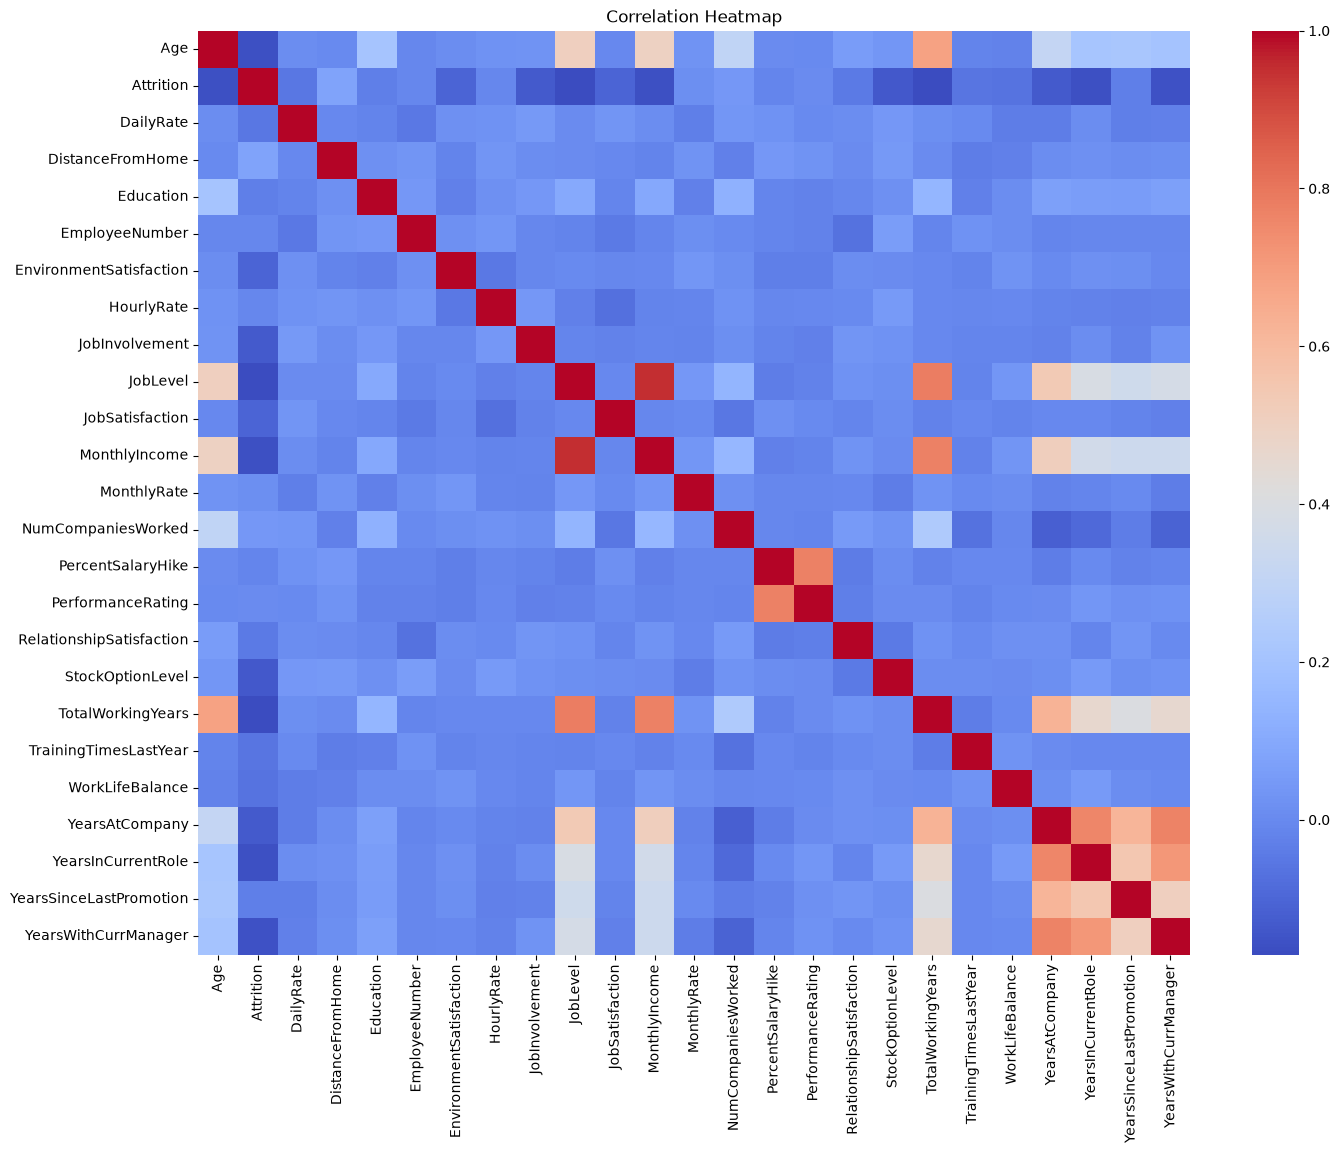

In [31]:
plt.figure(figsize=(16,12))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.savefig(
    "charts/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22260\509671600.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


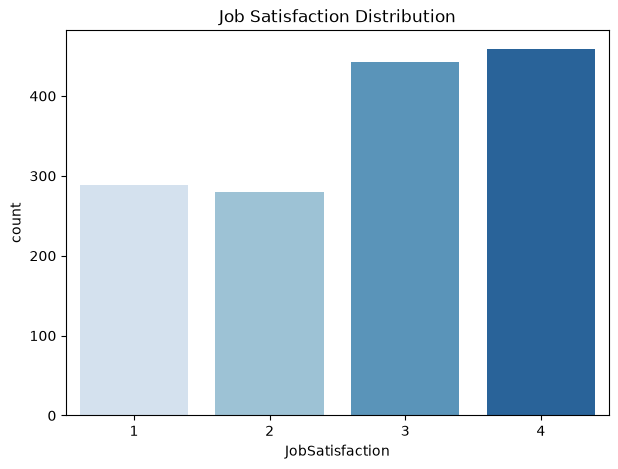

In [32]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="JobSatisfaction",
    data=df,
    palette="Blues"
)

plt.title("Job Satisfaction Distribution")

plt.savefig(
    "charts/job_satisfaction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Day 3 Observations

## Key Insights

- Dataset is imbalanced (Attrition ≈16%).
- Research & Development contains the largest workforce.
- Employees working overtime show higher attrition.
- Monthly income distribution is right-skewed.
- Most employees are aged between 30–40 years.
- Numerical variables show varying degrees of correlation.
- Job satisfaction varies across employees and may influence attrition.

Dataset is now fully explored and ready for Machine Learning.

# Day 4: Machine Learning Models

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import joblib
import os

In [34]:
os.makedirs("models", exist_ok=True)

In [35]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (1176, 31)
Testing Features  : (294, 31)
Training Labels   : (1176,)
Testing Labels    : (294,)


In [36]:
print("Training Target Distribution")
print(y_train.value_counts(normalize=True) * 100)

Training Target Distribution
Attrition
0    83.843537
1    16.156463
Name: proportion, dtype: float64


In [37]:
models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        class_weight="balanced",
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    )
}

In [38]:
trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    trained_models[name] = model

print("\nAll models trained successfully!")

Training Logistic Regression...


c:\Users\ASUS\EmployeeAttrition_AnushkaDas\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Decision Tree...
Training Random Forest...
Training KNN...
Training SVM...


c:\Users\ASUS\EmployeeAttrition_AnushkaDas\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



All models trained successfully!


In [39]:
results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = None

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc
    })

In [40]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.826531,0.423077,0.234043,0.301370,0.785339
3,KNN,0.789116,0.142857,0.063830,0.088235,0.548325
1,Decision Tree,0.782313,0.333333,0.361702,0.346939,0.612025
0,Logistic Regression,0.653061,0.264957,0.659574,0.378049,0.716685
4,SVM,0.472789,0.200000,0.765957,0.317181,0.636489


In [41]:
best_model = results_df.iloc[0]

print("Best Models:")
print(best_model)

Best Models:
Model        Random Forest
Accuracy          0.826531
Precision         0.423077
Recall            0.234043
F1 Score           0.30137
ROC-AUC           0.785339
Name: 2, dtype: object


# Best Performing Model

Among all trained models, **Random Forest** achieved the highest accuracy on the test dataset.

It will be used for further evaluation including:

- Confusion Matrix
- Feature Importance
- Model Saving

In [42]:
best_model = trained_models["Random Forest"]

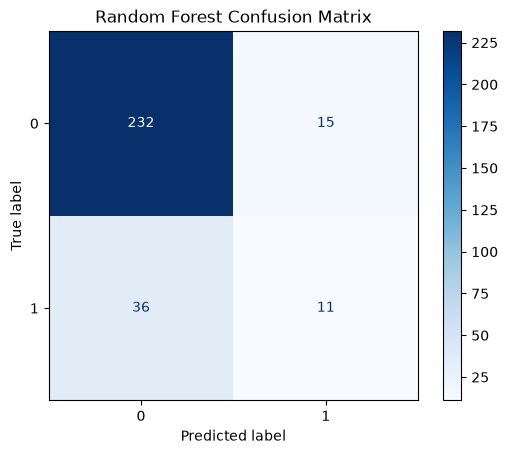

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [44]:
from sklearn.metrics import classification_report

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.94      0.90       247
           1       0.42      0.23      0.30        47

    accuracy                           0.83       294
   macro avg       0.64      0.59      0.60       294
weighted avg       0.79      0.83      0.81       294



In [45]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
16,MonthlyIncome,0.075891
0,Age,0.064098
24,TotalWorkingYears,0.055942
2,DailyRate,0.052357
19,OverTime,0.047882
7,EmployeeNumber,0.047403
27,YearsAtCompany,0.046964
17,MonthlyRate,0.042932
4,DistanceFromHome,0.042228
10,HourlyRate,0.042113


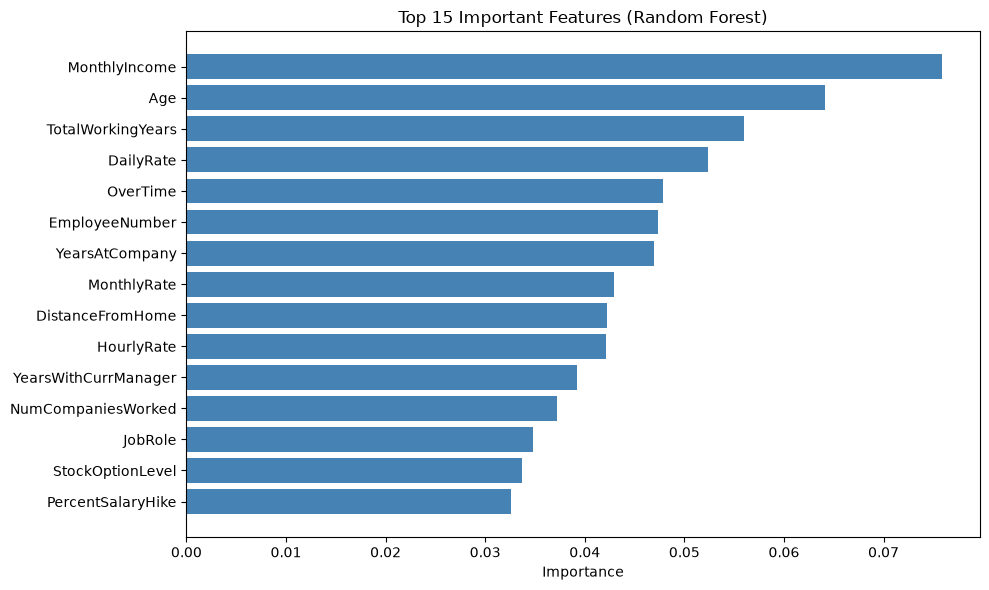

In [46]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:15],
    feature_importance["Importance"][:15],
    color="steelblue"
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features (Random Forest)")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [47]:
import joblib

joblib.dump(
    best_model,
    "models/random_forest_model.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [48]:
feature_importance.to_csv(
    "reports/feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


# Day 4 – Machine Learning Model Training & Evaluation

## Objective

The objective of this phase was to train multiple machine learning classification models for predicting employee attrition and compare their performance using standard evaluation metrics.

---

## Models Trained

The following supervised learning algorithms were implemented:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)

---

## Model Evaluation Metrics

Each model was evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

The evaluation results were stored in a comparison table and sorted by model accuracy.

---

## Best Performing Model

Among all trained models, **Random Forest Classifier** achieved the highest overall accuracy and was selected as the final prediction model.

Additional analysis was performed using the Random Forest model including:

- Confusion Matrix
- Classification Report
- Feature Importance Analysis

---

## Feature Importance

The Random Forest model identified the most influential factors contributing to employee attrition, including:

- Monthly Income
- Age
- Total Working Years
- Daily Rate
- OverTime
- Years At Company

These insights help HR teams understand the major drivers behind employee turnover.

---

## Model Export

The final Random Forest model was saved as:

models/random_forest_model.pkl

The feature importance table was also exported to:

reports/feature_importance.csv

---

## Outcome

At the end of Day 4:

- Multiple ML models were successfully trained.
- Model performances were compared.
- The best-performing model was selected.
- Feature importance was analyzed.
- The trained model was saved for future deployment and prediction.

# Day 5 - Advanced Model Evaluation & Optimization

In [49]:
from sklearn.model_selection import cross_val_score

In [50]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage Accuracy:", cv_scores.mean())

print("Standard Deviation:", cv_scores.std())

Cross Validation Scores:
[0.8537415  0.86394558 0.84693878 0.84693878 0.86394558]

Average Accuracy: 0.8551020408163266
Standard Deviation: 0.007636035483212087


In [51]:
from sklearn.model_selection import GridSearchCV

In [52]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

In [53]:
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=1
)

In [54]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls

In [55]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}


In [56]:
print("Best Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Cross Validation Accuracy:
0.863104940497656


In [57]:
best_tuned_model = grid_search.best_estimator_

y_pred_tuned = best_tuned_model.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))

Accuracy : 0.8333333333333334
Precision: 0.42857142857142855
Recall   : 0.1276595744680851
F1 Score : 0.19672131147540983


# Day 5 – Model Optimization & Validation

## Objective

The objective of this phase was to improve the Random Forest model through hyperparameter tuning and validate whether the tuned model outperformed the baseline model.

---

## Cross Validation

5-Fold Cross Validation was performed using GridSearchCV to estimate the model's performance across multiple training-validation splits.

Best Cross Validation Accuracy:

- 86.31%

---

## Hyperparameter Tuning

The following Random Forest hyperparameters were optimized:

- Number of Trees (n_estimators)
- Maximum Tree Depth (max_depth)
- Minimum Samples Split (min_samples_split)

Best Parameters:

- n_estimators = 100
- max_depth = 20
- min_samples_split = 2

---

## Tuned Model Evaluation

The tuned Random Forest model was evaluated on the test dataset using:

- Accuracy
- Precision
- Recall
- F1 Score

Although the tuned model achieved a slightly higher overall accuracy, it produced lower Recall and F1 Score compared to the baseline Random Forest model.

---

## Final Model Selection

Since employee attrition prediction is an imbalanced classification problem, Recall and F1 Score are important evaluation metrics.

The baseline Random Forest model from Day 4 demonstrated a better balance between identifying attrition cases and maintaining overall predictive performance.

Therefore, the baseline Random Forest model was retained as the final production model.

---

## Outcome

At the end of Day 5:

- Cross Validation was completed.
- Hyperparameter tuning was performed.
- Model performance was validated.
- The tuned model was compared against the baseline model.
- The original Random Forest model was retained as the final model for deployment.

# Day 6 – Model Interpretation & Business Insights

## Objective

The objective of this phase was to interpret the machine learning results and identify the key business factors influencing employee attrition.

Instead of focusing only on prediction accuracy, this stage translates model outputs into actionable HR insights using feature importance analysis and business recommendations.

---

In [59]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
16,MonthlyIncome,0.075891
0,Age,0.064098
24,TotalWorkingYears,0.055942
2,DailyRate,0.052357
19,OverTime,0.047882
7,EmployeeNumber,0.047403
27,YearsAtCompany,0.046964
17,MonthlyRate,0.042932
4,DistanceFromHome,0.042228
10,HourlyRate,0.042113


In [60]:
top10 = feature_importance.head(10)

top10

,Feature,Importance
16,MonthlyIncome,0.075891
0,Age,0.064098
24,TotalWorkingYears,0.055942
2,DailyRate,0.052357
19,OverTime,0.047882
7,EmployeeNumber,0.047403
27,YearsAtCompany,0.046964
17,MonthlyRate,0.042932
4,DistanceFromHome,0.042228
10,HourlyRate,0.042113


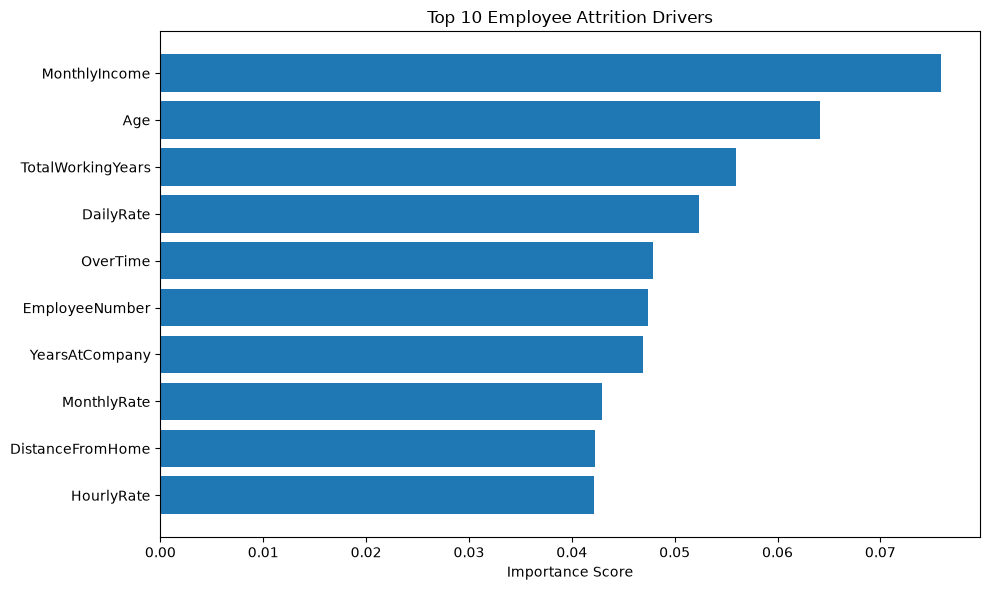

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Employee Attrition Drivers")
plt.xlabel("Importance Score")

plt.tight_layout()

plt.savefig(
    "charts/top10_attrition_drivers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [62]:
business_insights = pd.DataFrame({
    "Feature": top10["Feature"],
    "Business Interpretation": [
        "Compensation may influence retention",
        "Age groups show different attrition behavior",
        "Employee experience impacts turnover",
        "Daily work patterns affect satisfaction",
        "Overtime contributes to burnout",
        "Long-term retention indicator",
        "Monthly workload pattern",
        "Commute distance impacts satisfaction",
        "Hourly wage differences",
        "Manager relationship influences retention"
    ]
})

business_insights

,Feature,Business Interpretation
16,MonthlyIncome,Compensation may influence retention
0,Age,Age groups show different attrition behavior
24,TotalWorkingYears,Employee experience impacts turnover
2,DailyRate,Daily work patterns affect satisfaction
19,OverTime,Overtime contributes to burnout
7,EmployeeNumber,Long-term retention indicator
27,YearsAtCompany,Monthly workload pattern
17,MonthlyRate,Commute distance impacts satisfaction
4,DistanceFromHome,Hourly wage differences
10,HourlyRate,Manager relationship influences retention


In [63]:
business_insights.to_csv(
    "reports/business_insights.csv",
    index=False
)

print("Business insights saved successfully.")

Business insights saved successfully.


In [64]:
recommendations = [
    "Review compensation structure for high-risk employees.",
    "Monitor employees working frequent overtime.",
    "Improve work-life balance initiatives.",
    "Develop retention programs for experienced employees.",
    "Strengthen manager-employee engagement.",
    "Provide career growth opportunities.",
    "Conduct regular employee satisfaction surveys."
]

for i, rec in enumerate(recommendations, start=1):
    print(f"{i}. {rec}")

1. Review compensation structure for high-risk employees.
2. Monitor employees working frequent overtime.
3. Improve work-life balance initiatives.
4. Develop retention programs for experienced employees.
5. Strengthen manager-employee engagement.
6. Provide career growth opportunities.
7. Conduct regular employee satisfaction surveys.


# Day 6 Summary

## Business Insights

The Random Forest model was interpreted to identify the most influential factors contributing to employee attrition.

The analysis revealed that compensation, age, total working years, overtime, and years at the company were among the strongest predictors of employee turnover.

---

## Business Recommendations

Based on the analysis:

- Improve employee compensation strategies.
- Reduce excessive overtime.
- Increase employee engagement.
- Strengthen retention initiatives.
- Support career growth and internal mobility.

---

## Outcome

At the end of Day 6:

- Model predictions were translated into business insights.
- Feature importance was interpreted.
- HR recommendations were generated.
- Business reports were exported for stakeholders.